In [1]:
from core.lca import get_inventory_dataset, run_lca, compute_midpoint_contributions

In [2]:
# Brightway imports
import bw2data as bd
import brightway2 as bw

In [3]:
import pandas as pd

In [4]:
BW_PROJECT = 'metallican' # insert your project name here
bd.projects.set_current(BW_PROJECT)
list(bd.databases)

['biosphere3',
 'ecoinvent-3.10-cutoff',
 'Silver',
 'Gold',
 'Copper',
 'Iron',
 'Nickel',
 'Zinc',
 'biosphere3_spatialized_flows',
 'ecoinvent-3.10-cutoff regionalized',
 'Regioinvent',
 'tailings',
 'LIB raw materials',
 'IMAGE_SSP2L20',
 'IMAGE_SSP2L25',
 'IMAGE_SSP2L30',
 'IMAGE_SSP2L35',
 'IMAGE_SSP2L40',
 'metallican_lci',
 'IMAGE_SSP2L20 regionalized',
 'regioinvent',
 'IMAGE_SSP2M20',
 'IMAGE_SSP2M25',
 'IMAGE_SSP2M30',
 'IMAGE_SSP2M35',
 'IMAGE_SSP2M40']

In [5]:
IW_EP = [
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Human health', 'Total human health'),
    ('IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10', 'Ecosystem quality', 'Total ecosystem quality')
]
CC = [
    ('IMPACT World+ Midpoint 2.1_regionalized for ecoinvent v3.10', 'Midpoint', 'Climate change, long term'),
    ('IMPACT World+ Midpoint 2.1_regionalized for ecoinvent v3.10', 'Midpoint', 'Climate change, short term')
]


In [6]:
# Import IW+2.1. methods
IW_METHODS = [method for method in bd.methods if "impact world+" in " ".join(method).lower()]
#IW_METHODS

In [7]:
# Extract methods for IMPACT World+ Midpoint 2.1
IMPACT_METHODS_MIDPOINTS = [
    method for method in IW_METHODS
    if method[0] == 'IMPACT World+ Midpoint 2.1_regionalized for ecoinvent v3.10'
]
#IMPACT_METHODS_MIDPOINTS

In [8]:
# Extract methods for IMPACT World+ Damage 2.1
IMPACT_METHODS_DAMAGE = [
    method for method in IW_METHODS
    if method[0] == 'IMPACT World+ Damage 2.1_regionalized for ecoinvent v3.10'
]
#IMPACT_METHODS_DAMAGE

# Extract production and demand data

In [9]:
demand_df = pd.read_excel(r'data/data_lci.xlsx', sheet_name='DEMAND')
lci_demand = pd.read_excel(r'data/data_lci.xlsx', sheet_name='lci_demand')

In [10]:
year = [2025, 2030, 2035, 2040]
demand_df = demand_df[demand_df['Year'].isin(year)]

In [11]:
df_demand_agg = (demand_df
    .groupby(["Scenario", "Year", "Metal"])["Metal_demand_t"]
    .sum()
    .reset_index()
)


In [12]:
df_demand_agg['Metal_demand_kg'] = df_demand_agg['Metal_demand_t'] * 1e3

In [13]:
df_demand_cm = df_demand_agg[df_demand_agg['Scenario'] == 'Current Measures']
df_demand_nz = df_demand_agg[df_demand_agg['Scenario'] == 'Canada Net-zero']

In [14]:
df_demand_agg

,Scenario,Year,Metal,Metal_demand_t,Metal_demand_kg
0,Canada Net-zero,2025,Cobalt,1.885002e+04,1.885002e+07
1,Canada Net-zero,2025,Copper,1.979061e+06,1.979061e+09
2,Canada Net-zero,2025,Graphite,1.225692e+02,1.225692e+05
3,Canada Net-zero,2025,Lithium,5.254540e+03,5.254540e+06
4,Canada Net-zero,2025,Neodymium,3.253848e+02,3.253848e+05
...,...,...,...,...,...
67,Global Net-zero,2040,Copper,4.096053e+06,4.096053e+09
68,Global Net-zero,2040,Graphite,0.000000e+00,0.000000e+00
69,Global Net-zero,2040,Lithium,3.813993e+04,3.813993e+07
70,Global Net-zero,2040,Neodymium,7.054888e+03,7.054888e+06


In [15]:
lci_demand

,Metal,Activity,Reference Product,Location,Year,Scenario,DB_to_map
0,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2020,Current Measures,IMAGE_SSP2M20
1,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2020,Canada Net-zero,IMAGE_SSP2L20
2,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2025,Current Measures,IMAGE_SSP2M25
3,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2025,Canada Net-zero,IMAGE_SSP2L25
4,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2030,Current Measures,IMAGE_SSP2M30
5,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2030,Canada Net-zero,IMAGE_SSP2L30
6,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2035,Current Measures,IMAGE_SSP2M35
7,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2035,Canada Net-zero,IMAGE_SSP2L35
8,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2040,Current Measures,IMAGE_SSP2M40
9,Cobalt,market for cobalt sulfate,cobalt sulfate,World,2040,Canada Net-zero,IMAGE_SSP2L40


In [16]:
#lci_demand.to_csv(r'lci_demand.csv', index=False)
#df_demand_agg.to_csv(r'df_demand_agg.csv', index=False)

# LCA calculations

In [17]:
from core.lca import setup_activities, run_scenario_lca

In [18]:
lci_map = setup_activities(lci_demand)

In [19]:
lci_map

{('Current Measures',
  '2020',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Canada Net-zero',
  '2020',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Current Measures',
  '2025',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Canada Net-zero',
  '2025',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Current Measures',
  '2030',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Canada Net-zero',
  '2030',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Current Measures',
  '2035',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Canada Net-zero',
  '2035',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Current Measures',
  '2040',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Canada Net-zero',
  '2040',
  'Cobalt'): 'market for cobalt sulfate' (kilogram, World, None),
 ('Current Measures',
  '

In [24]:
import numpy as np
import brightway2 as bw
import pandas as pd
from brightway2 import Database
from brightway2 import LCA
import numpy as np

def run_scenario_lca(df_demand_agg, activities_dict, lcia_methods):
    """
    Compute scaled LCA results for each row in df_demand_agg.
    df_demand_agg must contain:
        scenario, year, metal, metal_demand_kg
    """

    results = []

    for idx, row in df_demand_agg.iterrows():
        scenario = row["Scenario"]
        year = str(row["Year"])
        metal = row["Metal"]
        qty = float(row["Metal_demand_kg"])

        key = (scenario, year, metal)
        activity = activities_dict.get(key, None)

        impact_results = {}

        if activity is None:
            for m in lcia_methods:
                impact_results[m[2]] = np.nan

        else:
            try:
                lca = LCA({activity: qty}, lcia_methods[0])
                lca.lci()

                for method in lcia_methods:
                    lca.switch_method(method)
                    lca.lcia()
                    impact_results[method[2]] = lca.score

            except:
                for m in lcia_methods:
                    impact_results[m[2]] = np.nan

        results.append({
            "Scenario": scenario,
            "Year": year,
            "Metal": metal,
            "Demand_kg": qty,
            **impact_results
        })

    return pd.DataFrame(results)

In [25]:
df_demand_lca = run_scenario_lca(df_demand_agg, lci_map, lcia_methods=IW_EP)

In [28]:
df_demand_lca

,Scenario,Year,Metal,Demand_kg,Total human health,Total ecosystem quality
0,Canada Net-zero,2025,Cobalt,1.885002e+07,2095.019789,2.021285e+08
1,Canada Net-zero,2025,Copper,1.979061e+09,472773.128198,6.889779e+10
2,Canada Net-zero,2025,Graphite,1.225692e+05,0.163080,2.338355e+04
3,Canada Net-zero,2025,Lithium,5.254540e+06,445.319532,4.697797e+07
4,Canada Net-zero,2025,Neodymium,3.253848e+05,155.801144,3.865857e+07
...,...,...,...,...,...,...
67,Global Net-zero,2040,Copper,4.096053e+09,NaN,NaN
68,Global Net-zero,2040,Graphite,0.000000e+00,NaN,NaN
69,Global Net-zero,2040,Lithium,3.813993e+07,NaN,NaN
70,Global Net-zero,2040,Neodymium,7.054888e+06,NaN,NaN


In [29]:
df_demand_lca.to_csv(r'results/LCA/df_demand_lca.csv', index=False)

In [30]:
from utils.visualisations import plot_lca_stackplots_by_scenario
from utils.constants import selected_metal_colors

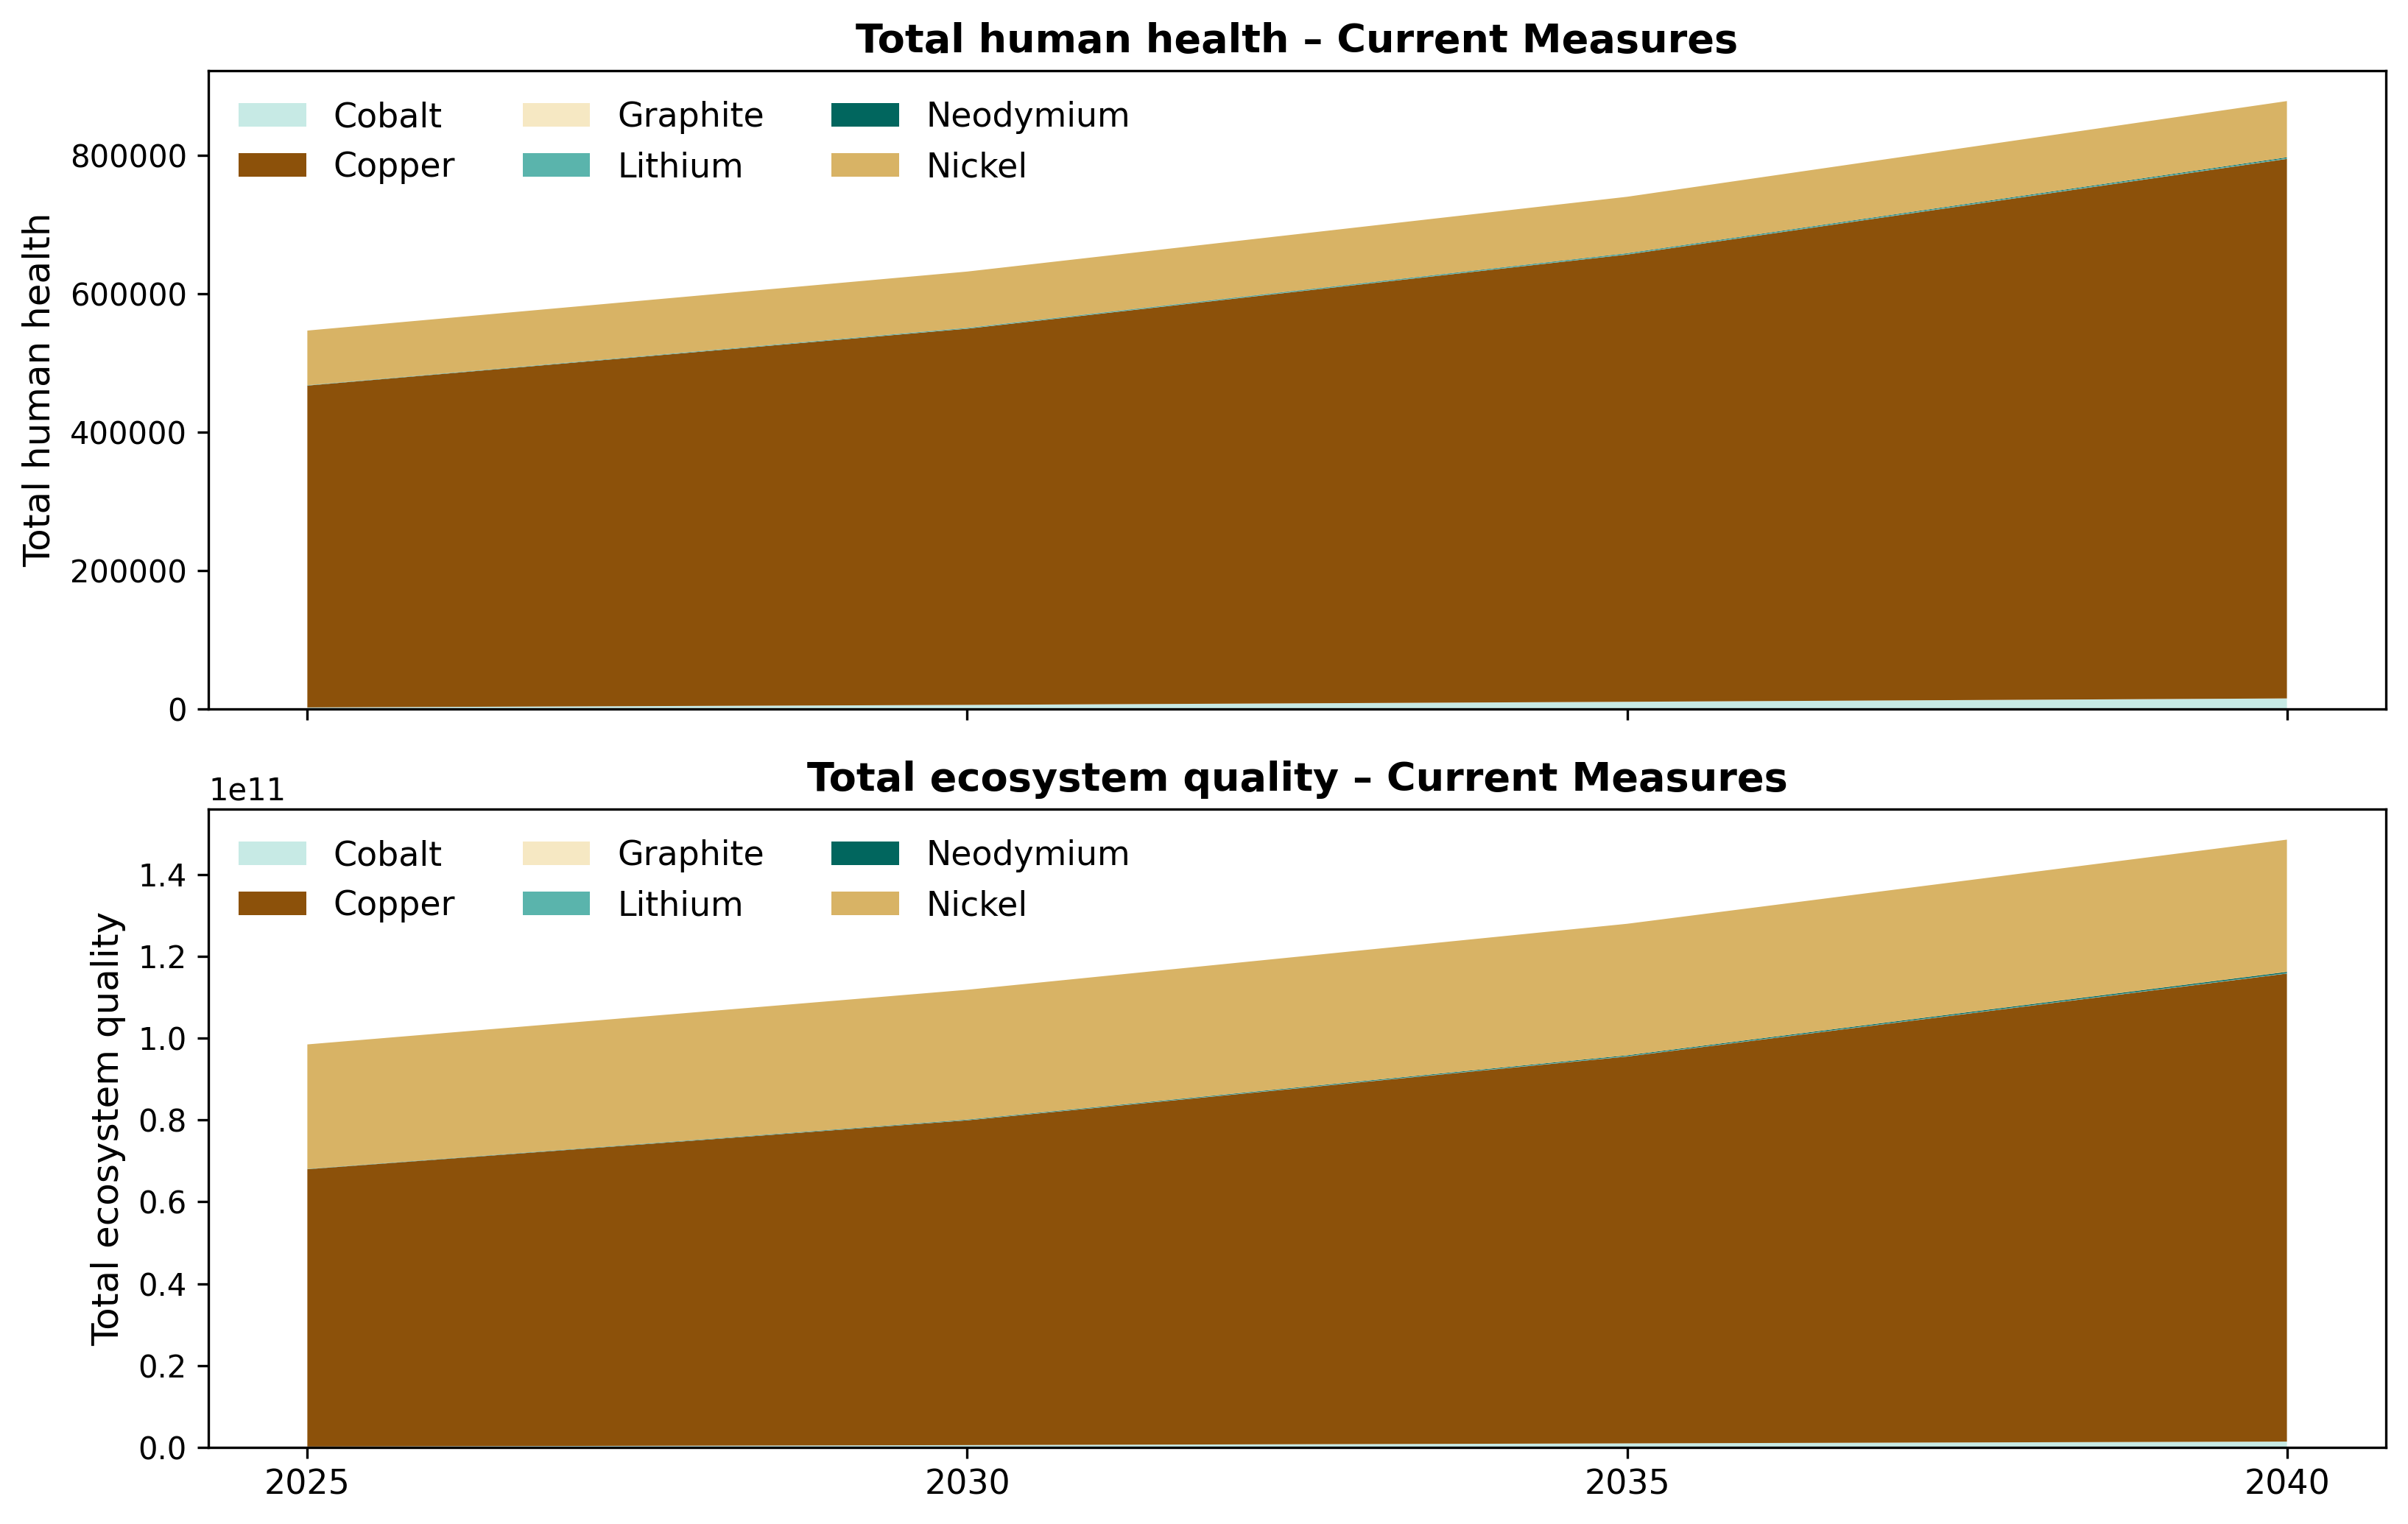

In [39]:
fig_cm = plot_lca_stackplots_by_scenario(
    df_demand_lca,
    scenario="Current Measures",
    impact_cols=["Total human health", "Total ecosystem quality"],
    color_map=selected_metal_colors,
    group_small_metals=False,   # ← NO aggregation
    figsize=(11, 7),
    savepath="results/LCA/current_measures_ep"
)


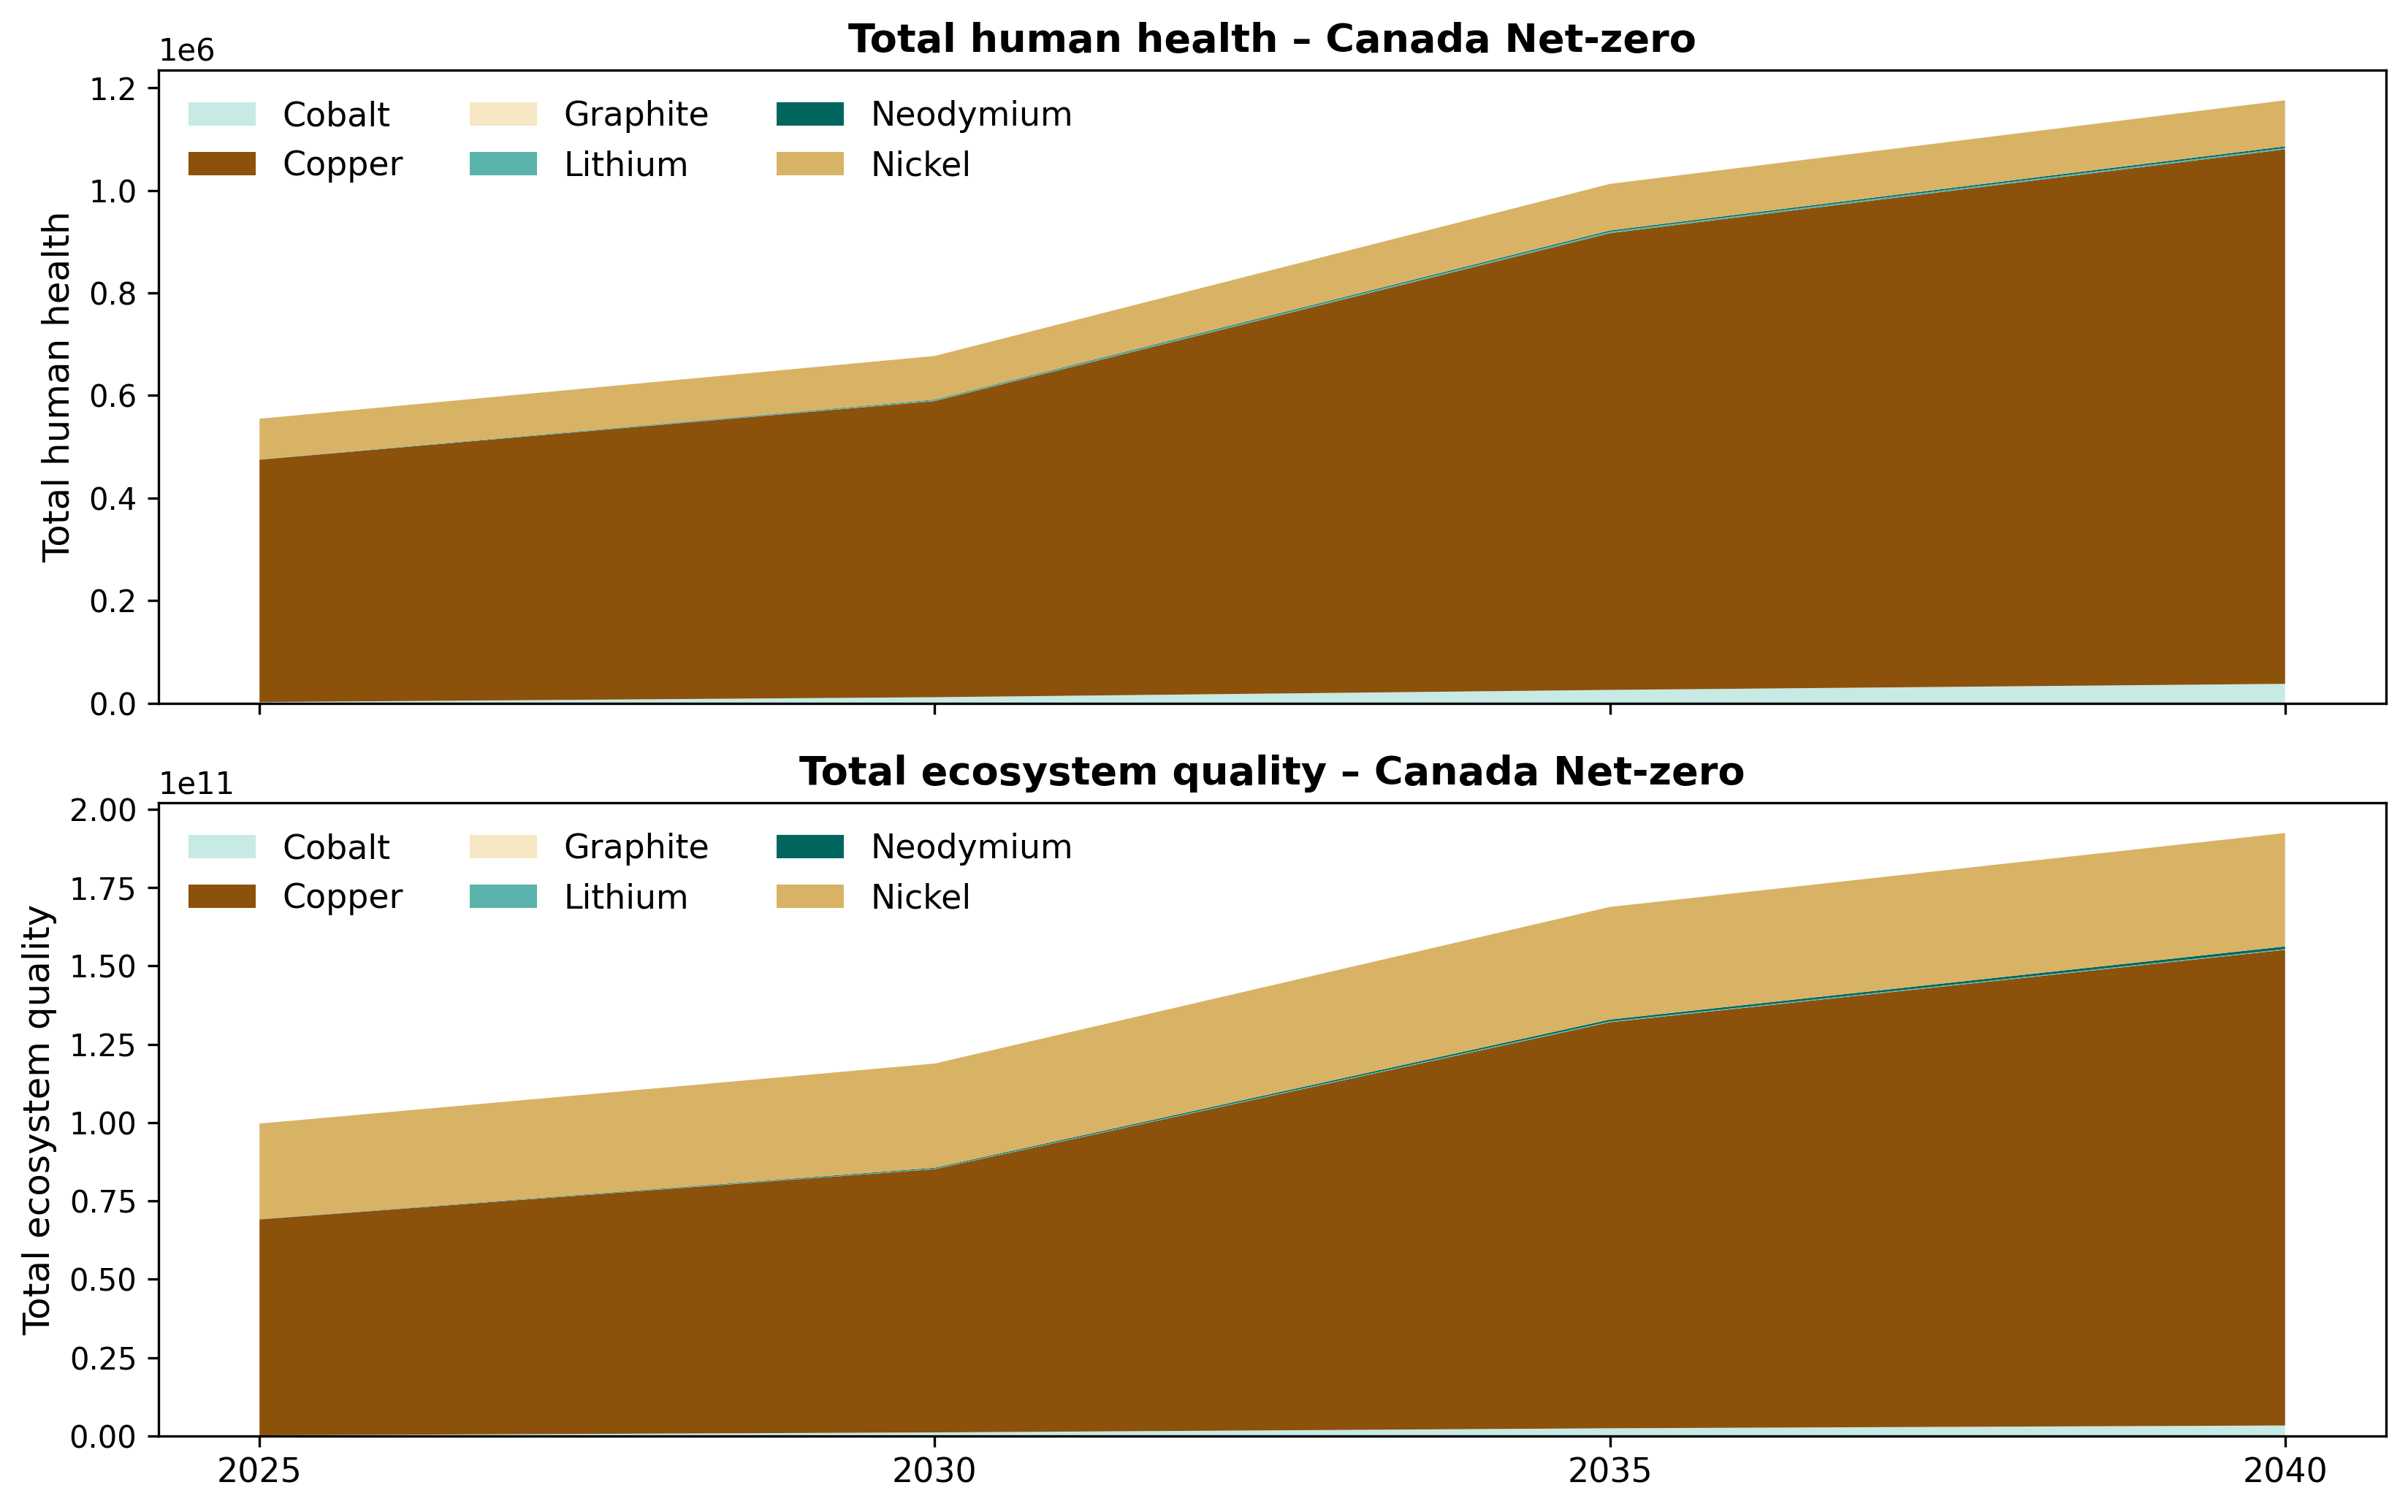

In [40]:
fig_nz = plot_lca_stackplots_by_scenario(
    df_demand_lca,
    scenario="Canada Net-zero",
    impact_cols=["Total human health", "Total ecosystem quality"],
    color_map=selected_metal_colors,
    group_small_metals=False,   # ← NO aggregation
    figsize=(11, 7),
    savepath="results/LCA/current_measures_nz"
)